In [3]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

Sleep questions:
- average hours of sleep per day (by week, by month)
- average hours of sleep by weekday
- average sleep score by week, month, weekday

In [4]:
sleep = pd.read_csv("../data/processed/clean/clean_sleep.csv")

Avg sleep for one instance, doesn't plot but does return values for whatever metric

In [20]:
def avg_sleep(df, year, group, target):
    sleep = (
        df [
            (df["year"] == year) &
            (df[group] == target) 
        ]["sleep_hours"]
        .mean()
    ).round(2)
    return sleep

print(avg_sleep(sleep, 2025, "month", 4))
print(avg_sleep(sleep, 2026, "week", 8))    

7.35
7.36


In [28]:
def avg_metric(df, year, group, target, metric):
    sleep = (
        df [
            (df["year"] == year) &
            (df[group] == target) 
        ][metric]
        .mean()
    ).round(2)
    return sleep

print(avg_metric(sleep, 2026, "month", 2, "overall_score"))
print(avg_metric(sleep, 2026, "month", 2, "sleep_hours"))



74.77
7.21


Beginnings of actually grouping data for visualization

<Axes: xlabel='year,week'>

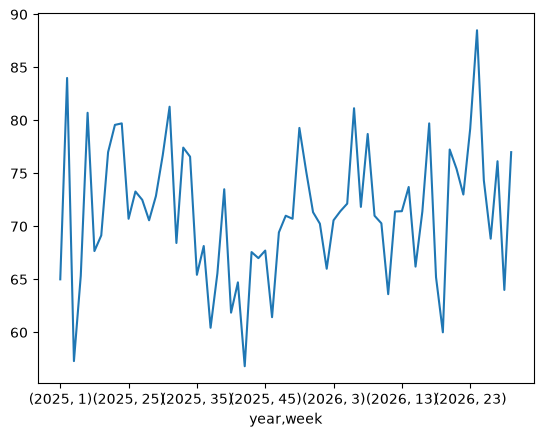

In [31]:
score_weekly = (sleep[sleep["overall_score"] != 0]
                .groupby(["year", "week"])["overall_score"]
                .mean())

score_weekly.plot()

<Axes: xlabel='weekday'>

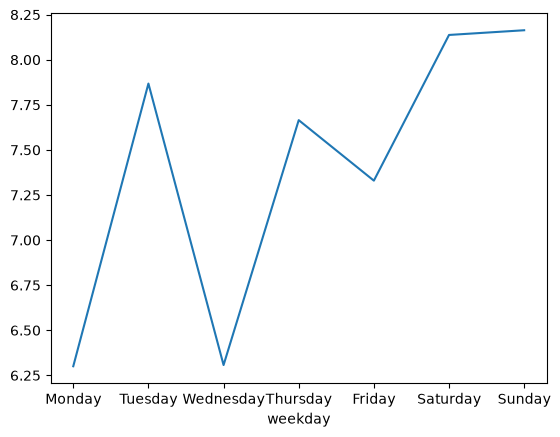

In [44]:
order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

hours_day = (sleep[sleep["year"] == 2026]
                .groupby(["weekday"])["sleep_hours"]
                .mean()
                .reindex(order))

hours_day.plot()

<Axes: xlabel='weekday'>

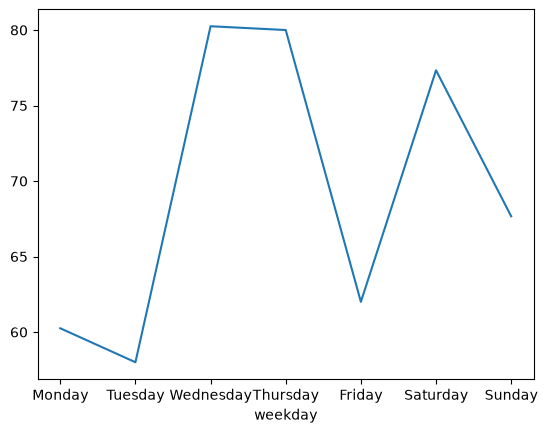

In [ ]:
hours_spec = (sleep[(sleep["year"] == 2026) & (sleep["month"] == 7)]
                .groupby(["weekday"])["sleep_hours"]
                .mean()
                .reindex(order))

hours_spec.plot()

Function that groups based on filters and metrics so that data can be visualized

<Axes: xlabel='weekday'>

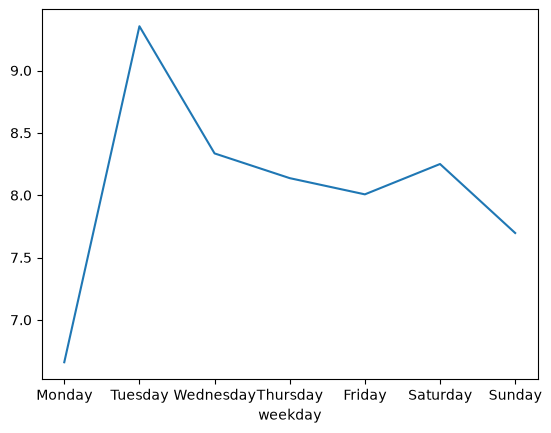

In [48]:
# trying to make versatile function for above filtered plots
def group_sleep(df, filters, group_by, metric, order=None):
    filtered = df.copy()

    for column, value in filters.items():
        filtered = filtered[filtered[column] == value]

    sleep_group = (
        filtered
        .groupby(group_by)[metric]
        .mean()
    )

    if order is not None:
        sleep_group = sleep_group.reindex(order)

    return sleep_group

hours_weekday = group_sleep(
    sleep,
    filters={"year": 2026, "month": 7},
    group_by="weekday",
    metric="sleep_hours",
    order=order
)
hours_weekday.plot()



<Axes: xlabel='month'>

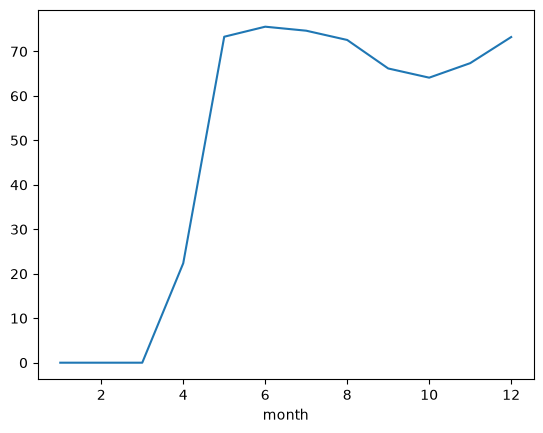

In [49]:
score_monthly = group_sleep(
    sleep,
    filters={"year": 2025},
    group_by="month",
    metric="overall_score"
)
score_monthly.plot()

<Axes: xlabel='weekday'>

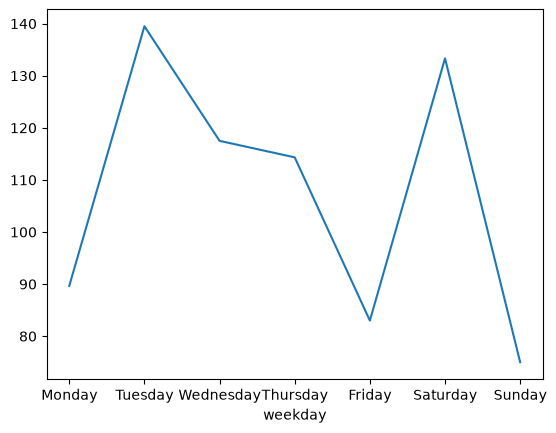

In [50]:
rem_by_weekday = group_sleep(
    sleep,
    filters={"year": 2026, "month": 7},
    group_by="weekday",
    metric="rem_minutes",
    order=order
)

rem_by_weekday.plot()